In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


SEPARAR DATASET EN ACTIVOS / ELIMINADOS

In [2]:
# Importando la biblioteca pandas para manipulación y análisis de datos
import pandas as pd
business_payments = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/merged_inner.csv')

In [3]:
business_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21057 entries, 0 to 21056
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          21057 non-null  int64  
 1   cash_request_id             21057 non-null  int64  
 2   type                        21057 non-null  object 
 3   status                      21057 non-null  object 
 4   category                    2196 non-null   object 
 5   total_amount                21057 non-null  float64
 6   reason                      21057 non-null  object 
 7   created_at                  21057 non-null  object 
 8   updated_at                  21057 non-null  object 
 9   paid_at                     15438 non-null  object 
 10  from_date                   6749 non-null   object 
 11  to_date                     6512 non-null   object 
 12  charge_moment               21057 non-null  object 
 13  amount                      210

In [14]:
import pandas as pd

# Cargar el archivo CSV original
file_path = 'drive/MyDrive/ColabNotebooks/Business_Payments/merged_inner.csv'  # Cambia esta ruta según corresponda
data = pd.read_csv(file_path)

# Separar los datos en usuarios activos y eliminados
usuarios_activos = data[data['user_id'].notna()]
usuarios_eliminados = data[data['deleted_account_id'].notna()]

# Guardar los datos en archivos CSV separados
usuarios_activos.to_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos.csv', index=False)
usuarios_eliminados.to_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados.csv.csv', index=False)

print("Archivos generados: 'usuarios_activos.csv' y 'usuarios_eliminados.csv'")


Archivos generados: 'usuarios_activos.csv' y 'usuarios_eliminados.csv'


--------------------------------------------------------------------------------------------------------

LIMPIEZA COLUMNAS Y CONVERSIÓN FECHAS
```



In [4]:
usuarios_activos = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos.csv')
usuarios_eliminados = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados.csv.csv')

In [8]:
# Eliminar columnas no necesarias
usuarios_activos = usuarios_activos.drop(columns=['deleted_account_id'], errors='ignore')
usuarios_eliminados = usuarios_eliminados.drop(columns=['user_id'], errors='ignore')

In [9]:
import pandas as pd
import pytz

# Definir la zona horaria deseada (puedes cambiar 'UTC' por otra como 'America/New_York')
desired_timezone = pytz.UTC

# Convertir columnas de fechas a datetime y ajustar al mismo timezone
date_columns = [
    'created_at', 'updated_at', 'paid_at', 'from_date', 'to_date',
    'cash_request_created_at', 'cash_request_updated_at', 'moderated_at',
    'reimbursement_date', 'cash_request_received_date', 'money_back_date',
    'send_at', 'reco_creation', 'reco_last_update'
]

for col in date_columns:
    if col in usuarios_activos.columns:
        # Convertir a datetime y manejar errores
        usuarios_activos[col] = pd.to_datetime(usuarios_activos[col], errors='coerce')

        # Ajustar al timezone deseado
        usuarios_activos[col] = usuarios_activos[col].apply(
            lambda x: x.tz_convert(desired_timezone) if pd.notnull(x) and x.tzinfo else (
                x.tz_localize('UTC').tz_convert(desired_timezone) if pd.notnull(x) else x
            )
        )

# Convertir identificadores a int (si no tienen valores faltantes)
id_columns = ['id', 'cash_request_id', 'user_id']

for col in id_columns:
    if col in usuarios_activos.columns:
        # Verificar si la columna contiene valores faltantes
        if usuarios_activos[col].isnull().any():
            print(f"La columna {col} tiene valores faltantes, no se convertirá a int.")
        else:
            usuarios_activos[col] = usuarios_activos[col].astype(int)

# Confirmar las conversiones
print(usuarios_activos.dtypes)



id                                          int64
cash_request_id                             int64
type                                       object
status                                     object
category                                   object
total_amount                              float64
reason                                     object
created_at                    datetime64[ns, UTC]
updated_at                    datetime64[ns, UTC]
paid_at                       datetime64[ns, UTC]
from_date                     datetime64[ns, UTC]
to_date                       datetime64[ns, UTC]
charge_moment                              object
amount                                    float64
cash_request_status                        object
cash_request_created_at       datetime64[ns, UTC]
cash_request_updated_at       datetime64[ns, UTC]
user_id                                     int64
moderated_at                  datetime64[ns, UTC]
reimbursement_date            datetime64[ns, UTC]


In [11]:
import pandas as pd
import pytz

# Definir la zona horaria deseada (puedes cambiar 'UTC' por otra como 'America/New_York')
desired_timezone = pytz.UTC

# Convertir columnas de fechas a datetime y ajustar al mismo timezone
date_columns = [
    'created_at', 'updated_at', 'paid_at', 'from_date', 'to_date',
    'cash_request_created_at', 'cash_request_updated_at', 'moderated_at',
    'reimbursement_date', 'cash_request_received_date', 'money_back_date',
    'send_at', 'reco_creation', 'reco_last_update'
]

for col in date_columns:
    if col in usuarios_eliminados.columns:
        # Convertir a datetime y manejar errores
        usuarios_eliminados[col] = pd.to_datetime(usuarios_eliminados[col], errors='coerce')

        # Ajustar al timezone deseado
        usuarios_eliminados[col] = usuarios_eliminados[col].apply(
            lambda x: x.tz_convert(desired_timezone) if pd.notnull(x) and x.tzinfo else (
                x.tz_localize('UTC').tz_convert(desired_timezone) if pd.notnull(x) else x
            )
        )

# Convertir identificadores a int (si no tienen valores faltantes)
id_columns = ['id', 'cash_request_id', 'deleted_account_id']

for col in id_columns:
    if col in usuarios_eliminados.columns:
        # Verificar si la columna contiene valores faltantes
        if usuarios_eliminados[col].isnull().any():
            print(f"La columna {col} tiene valores faltantes, no se convertirá a int.")
        else:
            usuarios_eliminados[col] = usuarios_eliminados[col].astype(int)

# Confirmar las conversiones
print(usuarios_eliminados.dtypes)


id                                          int64
cash_request_id                             int64
type                                       object
status                                     object
category                                   object
total_amount                              float64
reason                                     object
created_at                    datetime64[ns, UTC]
updated_at                    datetime64[ns, UTC]
paid_at                       datetime64[ns, UTC]
from_date                     datetime64[ns, UTC]
to_date                       datetime64[ns, UTC]
charge_moment                              object
amount                                    float64
cash_request_status                        object
cash_request_created_at       datetime64[ns, UTC]
cash_request_updated_at       datetime64[ns, UTC]
moderated_at                  datetime64[ns, UTC]
deleted_account_id                          int64
reimbursement_date            datetime64[ns, UTC]


COHORTES TRIMESTRALES

Usar cohortes trimestrales parece ser la mejor opción. El agrupamiento trimestral captura suficientemente los datos y evita la granularidad excesiva de un análisis mensual, especialmente considerando la distribución de los datos en los trimestres.



In [16]:
# Crear columna 'Trimestre' en usuarios activos
usuarios_activos['Trimestre'] = usuarios_activos['created_at'].dt.to_period('Q')

# Crear columna 'Trimestre' en usuarios eliminados
usuarios_eliminados['Trimestre'] = usuarios_eliminados['created_at'].dt.to_period('Q')

# Mostrar las primeras filas para verificar
print("Usuarios Activos con columna 'Trimestre':")
print(usuarios_activos.head())

print("\nUsuarios Eliminados con columna 'Trimestre':")
print(usuarios_eliminados.head())


<ipython-input-16-775b558dc212>:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  usuarios_activos['Trimestre'] = usuarios_activos['created_at'].dt.to_period('Q')
<ipython-input-16-775b558dc212>:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  usuarios_eliminados['Trimestre'] = usuarios_eliminados['created_at'].dt.to_period('Q')


Usuarios Activos con columna 'Trimestre':
      id  cash_request_id             type    status               category  \
0   6537            14941  instant_payment  rejected                    NaN   
1   6961            11714         incident  accepted  rejected_direct_debit   
2  16296            23371  instant_payment  accepted                    NaN   
3  20775            26772  instant_payment  accepted                    NaN   
4  17029            24052  instant_payment  accepted                    NaN   

   total_amount                              reason  \
0           5.0  Instant Payment Cash Request 14941   
1           5.0               rejected direct debit   
2           5.0  Instant Payment Cash Request 23371   
3           5.0  Instant Payment Cash Request 26772   
4           5.0  Instant Payment Cash Request 24052   

                        created_at                       updated_at  \
0 2020-09-07 10:47:27.423150+00:00 2020-10-13 14:25:09.396112+00:00   
1 2020-09-

In [17]:
# Crear columna 'Cohorte' en usuarios activos, basada en el trimestre de la primera solicitud
usuarios_activos['Cohorte'] = usuarios_activos.groupby('user_id')['created_at'].transform('min').dt.to_period('Q')

# Crear columna 'Cohorte' en usuarios eliminados, basada en el trimestre de la primera solicitud
usuarios_eliminados['Cohorte'] = usuarios_eliminados.groupby('deleted_account_id')['created_at'].transform('min').dt.to_period('Q')

# Mostrar las primeras filas de cada dataset para verificar
print("Usuarios Activos con columna 'Cohorte':")
print(usuarios_activos.head(10))

print("\nUsuarios Eliminados con columna 'Cohorte':")
print(usuarios_eliminados.head(10))


Usuarios Activos con columna 'Cohorte':
      id  cash_request_id             type     status               category  \
0   6537            14941  instant_payment   rejected                    NaN   
1   6961            11714         incident   accepted  rejected_direct_debit   
2  16296            23371  instant_payment   accepted                    NaN   
3  20775            26772  instant_payment   accepted                    NaN   
4  17029            24052  instant_payment   accepted                    NaN   
5  19956            25983  instant_payment   accepted                    NaN   
6  14187            14839         incident   accepted  rejected_direct_debit   
7  20539            26572  instant_payment   accepted                    NaN   
8  15431            22106         postpone  cancelled                    NaN   
9  17962            24756  instant_payment   accepted                    NaN   

   total_amount                              reason  \
0           5.0  Instant

<ipython-input-17-49e221261325>:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  usuarios_activos['Cohorte'] = usuarios_activos.groupby('user_id')['created_at'].transform('min').dt.to_period('Q')
<ipython-input-17-49e221261325>:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  usuarios_eliminados['Cohorte'] = usuarios_eliminados.groupby('deleted_account_id')['created_at'].transform('min').dt.to_period('Q')


In [18]:
# Calcular el número inicial de clientes únicos en cada cohorte para usuarios activos
cohort_sizes_activos = usuarios_activos.groupby('Cohorte').agg(
    Num_Clientes_Iniciales=('user_id', 'nunique')  # Número de clientes únicos
).reset_index()

# Calcular el número inicial de clientes únicos en cada cohorte para usuarios eliminados
cohort_sizes_eliminados = usuarios_eliminados.groupby('Cohorte').agg(
    Num_Clientes_Iniciales=('deleted_account_id', 'nunique')  # Número de clientes únicos
).reset_index()

# Mostrar los resultados
print("Tamaños de cohorte inicial para usuarios activos:")
print(cohort_sizes_activos)

print("\nTamaños de cohorte inicial para usuarios eliminados:")
print(cohort_sizes_eliminados)


Tamaños de cohorte inicial para usuarios activos:
  Cohorte  Num_Clientes_Iniciales
0  2020Q2                     409
1  2020Q3                    3555
2  2020Q4                    4908

Tamaños de cohorte inicial para usuarios eliminados:
  Cohorte  Num_Clientes_Iniciales
0  2020Q2                      49
1  2020Q3                     168
2  2020Q4                      91


In [20]:
# Calcular la cantidad de clientes únicos en cada cohorte trimestral para cada trimestre en usuarios activos
cohort_sizes_activos_trimestral = usuarios_activos.groupby(['Cohorte', 'Trimestre']).agg(
    Num_Clientes=('user_id', 'nunique')  # Número de clientes únicos
).reset_index()

# Calcular la cantidad de clientes únicos en cada cohorte trimestral para cada trimestre en usuarios eliminados
cohort_sizes_eliminados_trimestral = usuarios_eliminados.groupby(['Cohorte', 'Trimestre']).agg(
    Num_Clientes=('deleted_account_id', 'nunique')  # Número de clientes únicos
).reset_index()

# Mostrar resultados
print("Clientes únicos por cohorte y trimestre - Usuarios Activos:")
print(cohort_sizes_activos_trimestral)

print("\nClientes únicos por cohorte y trimestre - Usuarios Eliminados:")
print(cohort_sizes_eliminados_trimestral)


Clientes únicos por cohorte y trimestre - Usuarios Activos:
  Cohorte Trimestre  Num_Clientes
0  2020Q2    2020Q2           409
1  2020Q2    2020Q3           366
2  2020Q2    2020Q4           295
3  2020Q3    2020Q3          3555
4  2020Q3    2020Q4          2659
5  2020Q4    2020Q4          4908

Clientes únicos por cohorte y trimestre - Usuarios Eliminados:
  Cohorte Trimestre  Num_Clientes
0  2020Q2    2020Q2            49
1  2020Q2    2020Q3            38
2  2020Q2    2020Q4            17
3  2020Q3    2020Q3           168
4  2020Q3    2020Q4            68
5  2020Q4    2020Q4            91


In [21]:
# Calcular la cantidad de solicitudes de adelanto de efectivo para cada cohorte en cada trimestre para usuarios activos
cohort_cash_activos_trimestral = usuarios_activos.groupby(['Cohorte', 'Trimestre']).agg(
    Num_Solicitudes=('user_id', 'count')  # Número total de solicitudes
).reset_index()

# Calcular la cantidad de solicitudes de adelanto de efectivo para cada cohorte en cada trimestre para usuarios eliminados
cohort_cash_eliminados_trimestral = usuarios_eliminados.groupby(['Cohorte', 'Trimestre']).agg(
    Num_Solicitudes=('deleted_account_id', 'count')  # Número total de solicitudes
).reset_index()

# Mostrar resultados
print("Solicitudes de adelanto de efectivo por cohorte y trimestre - Usuarios Activos:")
print(cohort_cash_activos_trimestral)

print("\nSolicitudes de adelanto de efectivo por cohorte y trimestre - Usuarios Eliminados:")
print(cohort_cash_eliminados_trimestral)


Solicitudes de adelanto de efectivo por cohorte y trimestre - Usuarios Activos:
  Cohorte Trimestre  Num_Solicitudes
0  2020Q2    2020Q2              697
1  2020Q2    2020Q3             1155
2  2020Q2    2020Q4              419
3  2020Q3    2020Q3             7536
4  2020Q3    2020Q4             3905
5  2020Q4    2020Q4             6439

Solicitudes de adelanto de efectivo por cohorte y trimestre - Usuarios Eliminados:
  Cohorte Trimestre  Num_Solicitudes
0  2020Q2    2020Q2               88
1  2020Q2    2020Q3              154
2  2020Q2    2020Q4               24
3  2020Q3    2020Q3              394
4  2020Q3    2020Q4              109
5  2020Q4    2020Q4              137


In [22]:
# Calcular la cantidad de clientes únicos por cohorte y trimestre (similar a cohort_sizes_monthly)
cohort_sizes_activos_trimestral = usuarios_activos.groupby(['Cohorte', 'Trimestre']).agg(
    Num_Clientes=('user_id', 'nunique')
).reset_index()

cohort_sizes_eliminados_trimestral = usuarios_eliminados.groupby(['Cohorte', 'Trimestre']).agg(
    Num_Clientes=('deleted_account_id', 'nunique')
).reset_index()

# Calcular el número inicial de clientes por cohorte (cohort_sizes_initial)
cohort_sizes_initial_activos = usuarios_activos.groupby('Cohorte').agg(
    Num_Clientes_Iniciales=('user_id', 'nunique')
).reset_index()

cohort_sizes_initial_eliminados = usuarios_eliminados.groupby('Cohorte').agg(
    Num_Clientes_Iniciales=('deleted_account_id', 'nunique')
).reset_index()

# Crear la tabla de retención para usuarios activos
retention_activos = cohort_sizes_activos_trimestral.pivot(index='Cohorte', columns='Trimestre', values='Num_Clientes')
retention_activos = retention_activos.div(cohort_sizes_initial_activos.set_index('Cohorte')['Num_Clientes_Iniciales'], axis=0)

# Crear la tabla de retención para usuarios eliminados
retention_eliminados = cohort_sizes_eliminados_trimestral.pivot(index='Cohorte', columns='Trimestre', values='Num_Clientes')
retention_eliminados = retention_eliminados.div(cohort_sizes_initial_eliminados.set_index('Cohorte')['Num_Clientes_Iniciales'], axis=0)

# Mostrar resultados
print("Tasa de retención de clientes - Usuarios Activos:")
print(retention_activos)

print("\nTasa de retención de clientes - Usuarios Eliminados:")
print(retention_eliminados)


Tasa de retención de clientes - Usuarios Activos:
Trimestre  2020Q2    2020Q3    2020Q4
Cohorte                              
2020Q2        1.0  0.894866  0.721271
2020Q3        NaN  1.000000  0.747961
2020Q4        NaN       NaN  1.000000

Tasa de retención de clientes - Usuarios Eliminados:
Trimestre  2020Q2   2020Q3    2020Q4
Cohorte                             
2020Q2        1.0  0.77551  0.346939
2020Q3        NaN  1.00000  0.404762
2020Q4        NaN      NaN  1.000000


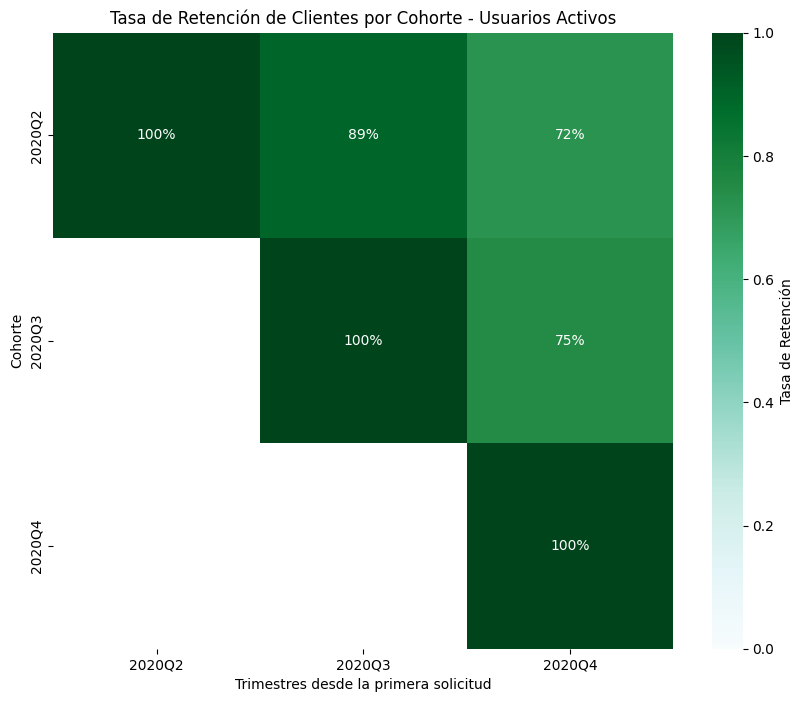

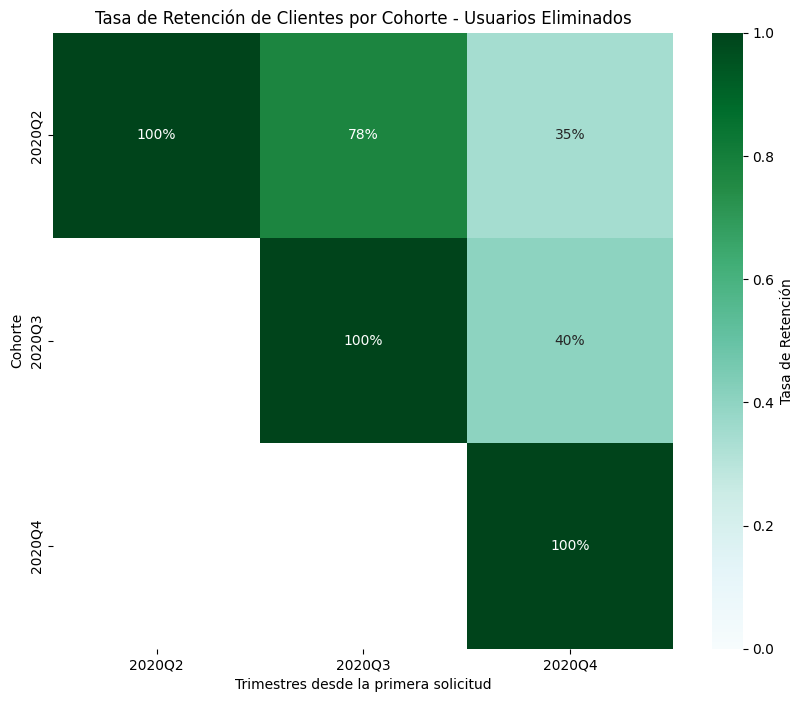

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizar la tasa de retención de clientes para usuarios activos
plt.figure(figsize=(10, 8))
plt.title('Tasa de Retención de Clientes por Cohorte - Usuarios Activos')
sns.heatmap(
    data=retention_activos,
    annot=True,
    fmt='.0%',
    vmin=0.0,
    vmax=1.0,
    cmap='BuGn',
    cbar_kws={'label': 'Tasa de Retención'}
)
plt.xlabel('Trimestres desde la primera solicitud')
plt.ylabel('Cohorte')
plt.show()

# Visualizar la tasa de retención de clientes para usuarios eliminados
plt.figure(figsize=(10, 8))
plt.title('Tasa de Retención de Clientes por Cohorte - Usuarios Eliminados')
sns.heatmap(
    data=retention_eliminados,
    annot=True,
    fmt='.0%',
    vmin=0.0,
    vmax=1.0,
    cmap='BuGn',
    cbar_kws={'label': 'Tasa de Retención'}
)
plt.xlabel('Trimestres desde la primera solicitud')
plt.ylabel('Cohorte')
plt.show()


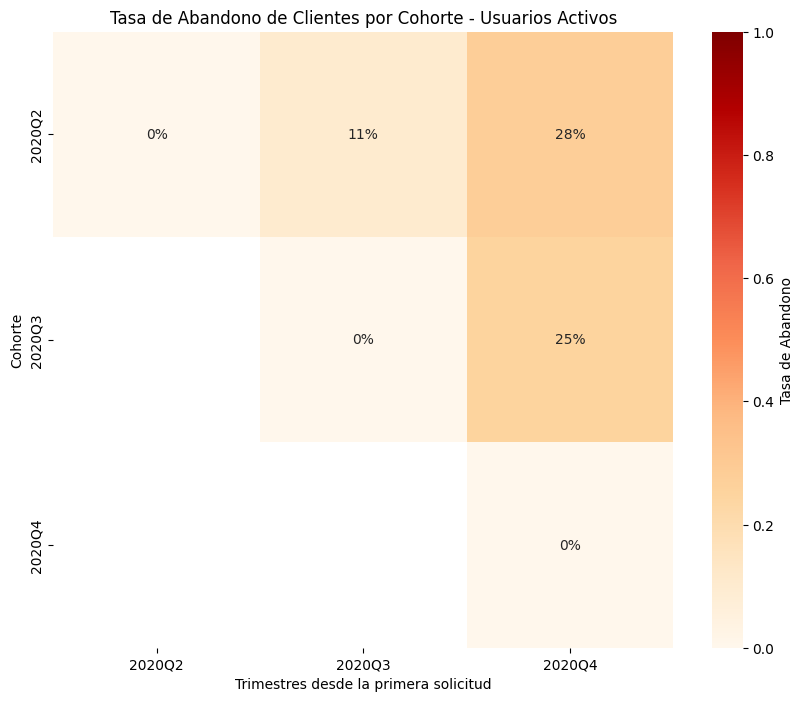

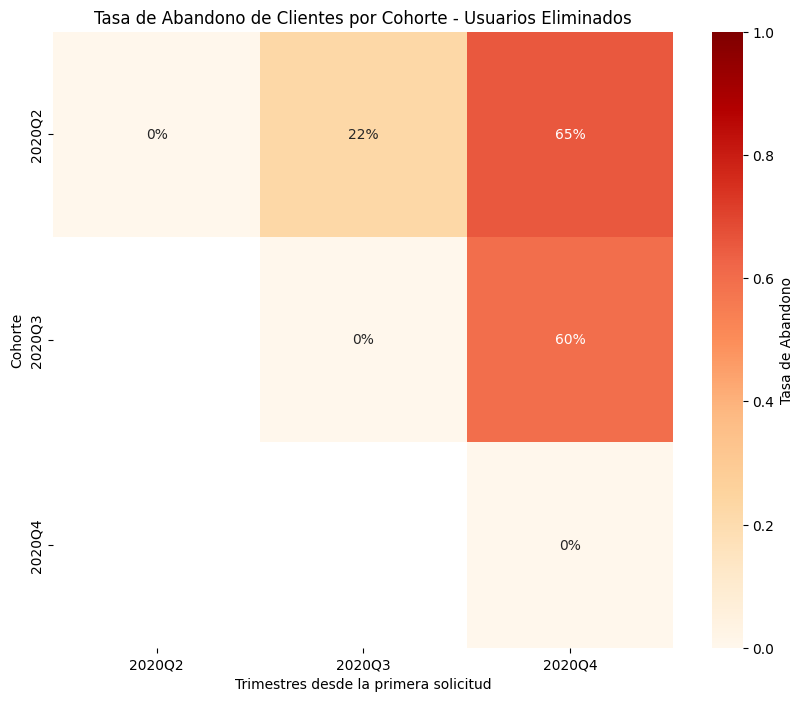

In [24]:
# Calcular la tasa de abandono de clientes (1 - tasa de retención)
churn_activos = 1 - retention_activos
churn_eliminados = 1 - retention_eliminados

# Visualizar la tasa de abandono de clientes para usuarios activos
plt.figure(figsize=(10, 8))
plt.title('Tasa de Abandono de Clientes por Cohorte - Usuarios Activos')
sns.heatmap(
    data=churn_activos,
    annot=True,
    fmt='.0%',
    vmin=0.0,
    vmax=1.0,
    cmap='OrRd',
    cbar_kws={'label': 'Tasa de Abandono'}
)
plt.xlabel('Trimestres desde la primera solicitud')
plt.ylabel('Cohorte')
plt.show()

# Visualizar la tasa de abandono de clientes para usuarios eliminados
plt.figure(figsize=(10, 8))
plt.title('Tasa de Abandono de Clientes por Cohorte - Usuarios Eliminados')
sns.heatmap(
    data=churn_eliminados,
    annot=True,
    fmt='.0%',
    vmin=0.0,
    vmax=1.0,
    cmap='OrRd',
    cbar_kws={'label': 'Tasa de Abandono'}
)
plt.xlabel('Trimestres desde la primera solicitud')
plt.ylabel('Cohorte')
plt.show()


In [25]:
# Calcular el número inicial de solicitudes de adelanto de efectivo en cada cohorte para usuarios activos
cohort_cash_initial_activos = cohort_cash_activos_trimestral.groupby('Cohorte').first().reset_index().rename(
    columns={'Num_Solicitudes': 'Num_Solicitudes_Iniciales'}
)

# Calcular el número inicial de solicitudes de adelanto de efectivo en cada cohorte para usuarios eliminados
cohort_cash_initial_eliminados = cohort_cash_eliminados_trimestral.groupby('Cohorte').first().reset_index().rename(
    columns={'Num_Solicitudes': 'Num_Solicitudes_Iniciales'}
)

# Mostrar resultados
print("Número inicial de solicitudes de adelanto de efectivo por cohorte - Usuarios Activos:")
print(cohort_cash_initial_activos)

print("\nNúmero inicial de solicitudes de adelanto de efectivo por cohorte - Usuarios Eliminados:")
print(cohort_cash_initial_eliminados)


Número inicial de solicitudes de adelanto de efectivo por cohorte - Usuarios Activos:
  Cohorte Trimestre  Num_Solicitudes_Iniciales
0  2020Q2    2020Q2                        697
1  2020Q3    2020Q3                       7536
2  2020Q4    2020Q4                       6439

Número inicial de solicitudes de adelanto de efectivo por cohorte - Usuarios Eliminados:
  Cohorte Trimestre  Num_Solicitudes_Iniciales
0  2020Q2    2020Q2                         88
1  2020Q3    2020Q3                        394
2  2020Q4    2020Q4                        137


In [26]:
# Crear una tabla pivote con el número de solicitudes por cohorte y trimestre para usuarios activos
retention_cash_activos = cohort_cash_activos_trimestral.pivot(index='Cohorte', columns='Trimestre', values='Num_Solicitudes')

# Dividir cada celda por el número inicial de solicitudes de la cohorte para calcular la tasa de retención
retention_cash_activos = retention_cash_activos.div(
    cohort_cash_initial_activos.set_index('Cohorte')['Num_Solicitudes_Iniciales'],
    axis=0
)

# Crear una tabla pivote con el número de solicitudes por cohorte y trimestre para usuarios eliminados
retention_cash_eliminados = cohort_cash_eliminados_trimestral.pivot(index='Cohorte', columns='Trimestre', values='Num_Solicitudes')

# Dividir cada celda por el número inicial de solicitudes de la cohorte para calcular la tasa de retención
retention_cash_eliminados = retention_cash_eliminados.div(
    cohort_cash_initial_eliminados.set_index('Cohorte')['Num_Solicitudes_Iniciales'],
    axis=0
)

# Mostrar resultados
print("Tasa de retención de solicitudes - Usuarios Activos:")
print(retention_cash_activos)

print("\nTasa de retención de solicitudes - Usuarios Eliminados:")
print(retention_cash_eliminados)


Tasa de retención de solicitudes - Usuarios Activos:
Trimestre  2020Q2    2020Q3    2020Q4
Cohorte                              
2020Q2        1.0  1.657102  0.601148
2020Q3        NaN  1.000000  0.518179
2020Q4        NaN       NaN  1.000000

Tasa de retención de solicitudes - Usuarios Eliminados:
Trimestre  2020Q2  2020Q3    2020Q4
Cohorte                            
2020Q2        1.0    1.75  0.272727
2020Q3        NaN    1.00  0.276650
2020Q4        NaN     NaN  1.000000


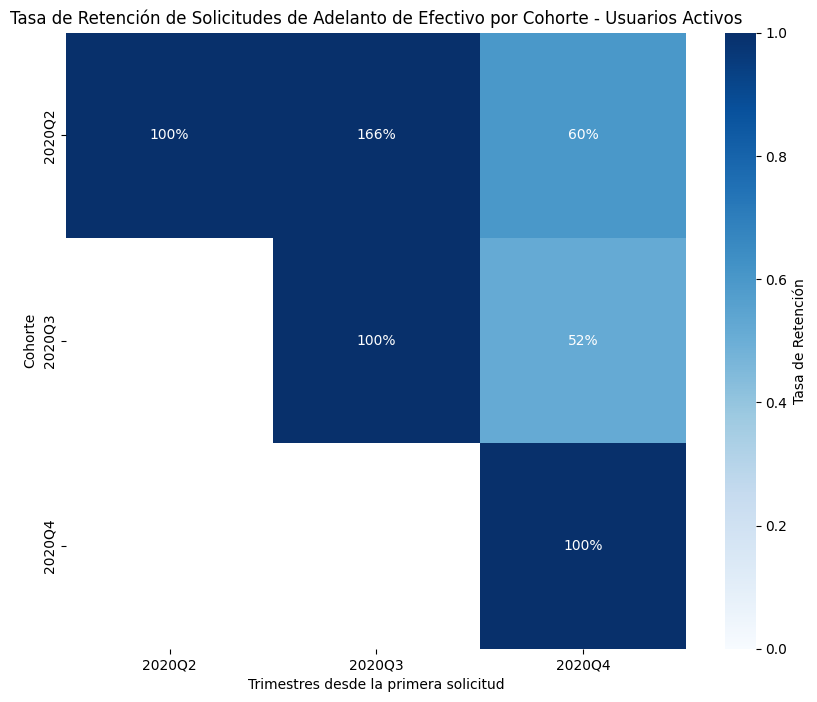

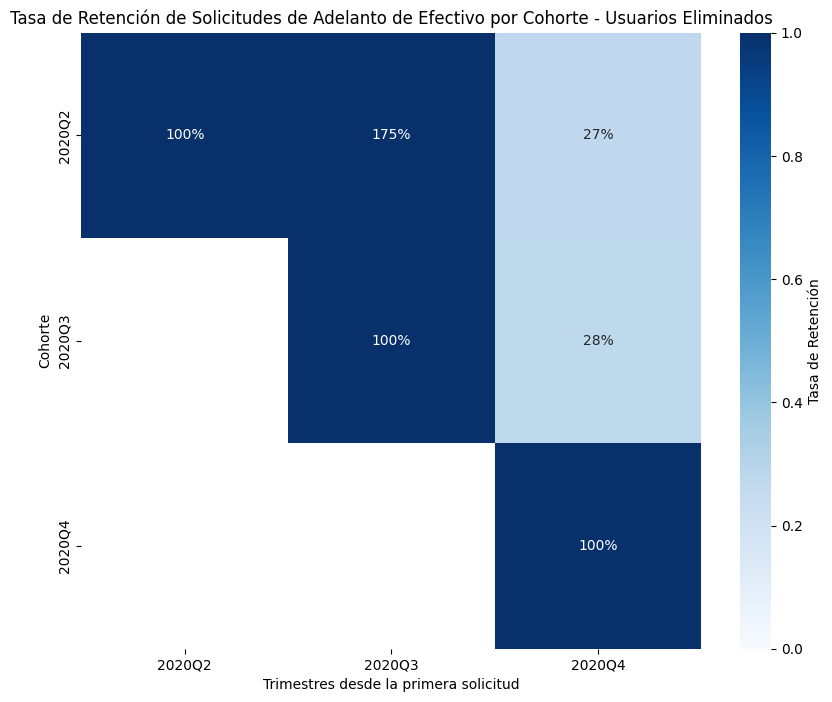

In [27]:
# Visualizar la tasa de retención de solicitudes para usuarios activos
plt.figure(figsize=(10, 8))
plt.title('Tasa de Retención de Solicitudes de Adelanto de Efectivo por Cohorte - Usuarios Activos')
sns.heatmap(
    data=retention_cash_activos,
    annot=True,
    fmt='.0%',
    vmin=0.0,
    vmax=1.0,
    cmap='Blues',
    cbar_kws={'label': 'Tasa de Retención'}
)
plt.xlabel('Trimestres desde la primera solicitud')
plt.ylabel('Cohorte')
plt.show()

# Visualizar la tasa de retención de solicitudes para usuarios eliminados
plt.figure(figsize=(10, 8))
plt.title('Tasa de Retención de Solicitudes de Adelanto de Efectivo por Cohorte - Usuarios Eliminados')
sns.heatmap(
    data=retention_cash_eliminados,
    annot=True,
    fmt='.0%',
    vmin=0.0,
    vmax=1.0,
    cmap='Blues',
    cbar_kws={'label': 'Tasa de Retención'}
)
plt.xlabel('Trimestres desde la primera solicitud')
plt.ylabel('Cohorte')
plt.show()


In [28]:
# Calcular la tasa de abandono de solicitudes para usuarios activos
churn_cash_activos = 1 - retention_cash_activos

# Calcular la tasa de abandono de solicitudes para usuarios eliminados
churn_cash_eliminados = 1 - retention_cash_eliminados

# Mostrar los resultados
print("Tasa de abandono de solicitudes - Usuarios Activos:")
print(churn_cash_activos)

print("\nTasa de abandono de solicitudes - Usuarios Eliminados:")
print(churn_cash_eliminados)


Tasa de abandono de solicitudes - Usuarios Activos:
Trimestre  2020Q2    2020Q3    2020Q4
Cohorte                              
2020Q2        0.0 -0.657102  0.398852
2020Q3        NaN  0.000000  0.481821
2020Q4        NaN       NaN  0.000000

Tasa de abandono de solicitudes - Usuarios Eliminados:
Trimestre  2020Q2  2020Q3    2020Q4
Cohorte                            
2020Q2        0.0   -0.75  0.727273
2020Q3        NaN    0.00  0.723350
2020Q4        NaN     NaN  0.000000


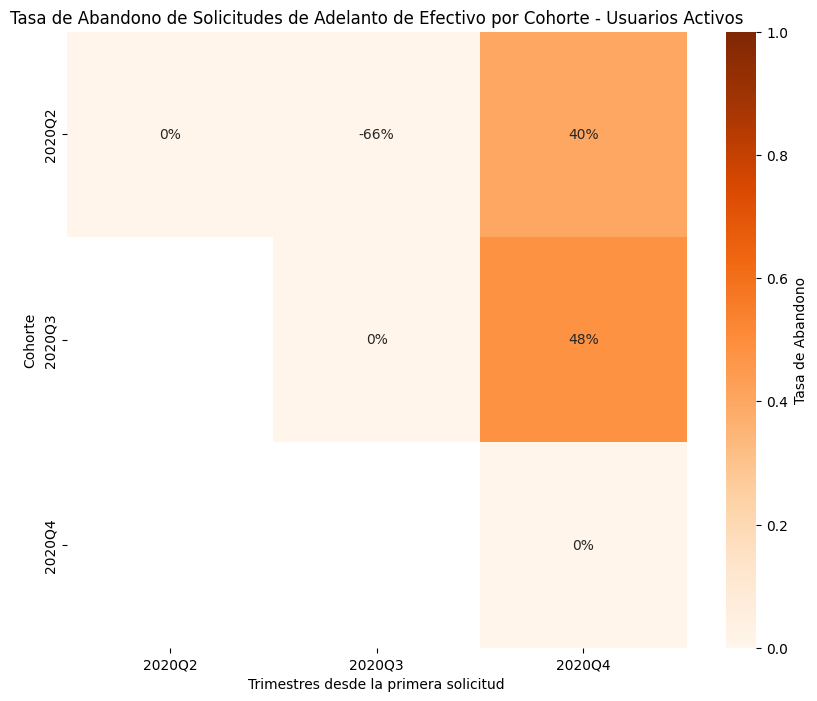

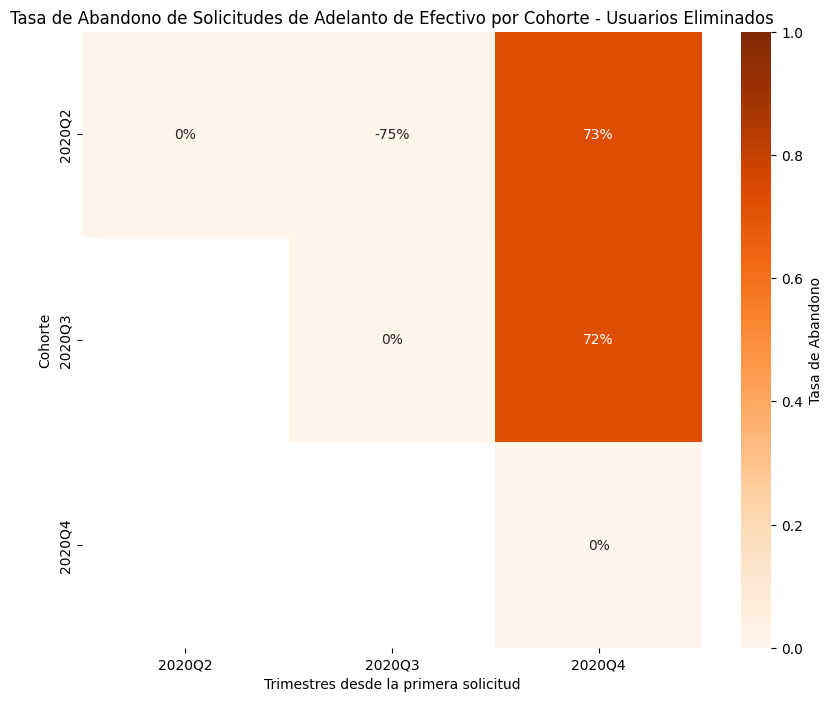

In [29]:
# Visualizar la tasa de abandono de solicitudes para usuarios activos
plt.figure(figsize=(10, 8))
plt.title('Tasa de Abandono de Solicitudes de Adelanto de Efectivo por Cohorte - Usuarios Activos')
sns.heatmap(
    data=churn_cash_activos,
    annot=True,
    fmt='.0%',
    vmin=0.0,
    vmax=1.0,
    cmap='Oranges',
    cbar_kws={'label': 'Tasa de Abandono'}
)
plt.xlabel('Trimestres desde la primera solicitud')
plt.ylabel('Cohorte')
plt.show()

# Visualizar la tasa de abandono de solicitudes para usuarios eliminados
plt.figure(figsize=(10, 8))
plt.title('Tasa de Abandono de Solicitudes de Adelanto de Efectivo por Cohorte - Usuarios Eliminados')
sns.heatmap(
    data=churn_cash_eliminados,
    annot=True,
    fmt='.0%',
    vmin=0.0,
    vmax=1.0,
    cmap='Oranges',
    cbar_kws={'label': 'Tasa de Abandono'}
)
plt.xlabel('Trimestres desde la primera solicitud')
plt.ylabel('Cohorte')
plt.show()
